# Test Uniform Sampling

In [ ]:
import torch
import numpy as np
from omegaconf import OmegaConf
from functools import partial
import gymnasium as gym
import matplotlib.pyplot as plt

import time

import bbrl_utils
from bbrl_utils.notebook import setup_tensorboard
from bbrl.stats import WelchTTest
from bbrl.agents import Agent, Agents, TemporalAgent
from bbrl.agents.gymnasium import ParallelGymAgent, make_env
from bbrl.workspace import Workspace
from bbrl.utils.replay_buffer import ReplayBuffer

import bbrl_gymnasium

from pmind.algorithms import DQN, DDPG, TD3, OfflineTD3
from pmind.losses import dqn_compute_critic_loss, ddqn_compute_critic_loss
from pmind.training import (
    run_dqn,
    run_ddpg,
    run_td3,
    # run_td3_offline,
    # load_trained_agents,
)
from pmind.replay import (
    collect_policy_transitions,
    collect_uniform_transitions,
    mix_transitions,
    test_rb_uniform_proportions,
)

from pmind.visualization import plot_perf_vs_rb_composition_from_dict

from pmind.config.loader import load_config

bbrl_utils.setup()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [134]:
ENV_NAME = (
    "CartPoleContinuous-v1",
    "Pendulum-v1",
    "MountainCarContinuous-v0",
    "LunarLanderContinuous-v3",
)[1]

from pmind.replay import UniformExplorationWrapper
env = gym.make(ENV_NAME,render_mode="rgb_array")
env = UniformExplorationWrapper(env)
rb_unif = collect_uniform_transitions(ENV_NAME, buffer_size=100)

100%|██████████| 100/100 [00:00<00:00, 12316.63it/s]

0 of proposed states were rejected


(array([ 0.35717914, -0.9340359 , -0.48224655], dtype=float32), {})
[-1.20555028 -0.48224656]


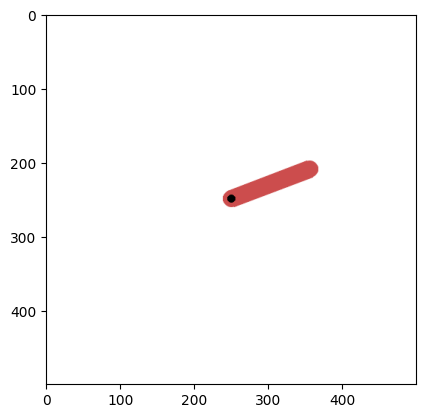

In [131]:
obs = env.uniform_reset()
print(obs)
print(env.unwrapped.state)
plt.imshow(env.render())

# Comments on each environment:

All wrapped environments have no `state` variable, only `unwrapped.state`, so it makes no sense to set `state` variable of wrapped environment.

- CartPole:
    - seems ok
- Pendulum:
    - `.reset()` is already uniform for angle and angular velocity
    - so seems okay without any intervention
- MountainCar:
    - seems ok
- LunarLander:
    - even unwrapped environment has no state variable
    - rotations and interaction of legs with ground make it trickier


# Attempts for LunarLander

In [ ]:
# env.reset()

# x, y, xdot, ydot, th, thdot, left_contact, right_contact =  env.observation_space.sample()
# x = float(x)
# y =float(y) 
# xdot = float(xdot) 
# ydot = float(ydot) 
# th = float(th) 
# thdot = float(thdot) 
# left_contact = bool(left_contact > 0.5)
# right_contact = bool(right_contact > 0.5)

# lander = env.unwrapped.lander
# lander.position = (x, y)
# lander.linearVelocity.x = xdot
# lander.linearVelocity.y = ydot
# lander.angle = th
# lander.angularVelocity = thdot

# legs = env.unwrapped.legs
# legs[0].ground_contact = bool(left_contact)
# legs[1].ground_contact = bool(right_contact)

In [ ]:
env.reset()
body = env.unwrapped.lander
legs = env.unwrapped.legs

dx = np.random.uniform(-10, 10)
dy = np.random.uniform(-1, -10)

# move body
body.position = (body.position[0] + dx,body.position[1] + dy)

# move legs with same translation
for leg in legs:
    leg.position = (leg.position[0] + dx, leg.position[1] + dy)
    
vx = np.random.uniform(-1,1)
vy = np.random.uniform(-1,0)
vth = np.random.uniform(-1, 1)

body.linearVelocity = (vx, vy)
for leg in legs:
    leg.linearVelocity = (vx, vy)
    
th = np.random.uniform(-0.2, 0.2)

# body.angle = th
# for leg in legs:
#     leg.angle = th
    
# body.angularVelocity = vth
# for leg in legs:
#     leg.angularVelocity = vth
obs, *_ = env.step([0, 0]) # do nothing, just to detect whether ground was touched
print(obs)
plt.imshow(env.render())

[autoreload of pmind.replay failed: Traceback (most recent call last):
  File "/Users/vlad/Documents/University/Master-MIND/projet-mind/.venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/Users/vlad/Documents/University/Master-MIND/projet-mind/.venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/Users/vlad/Documents/University/Master-MIND/projet-mind/.venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/Users/vlad/Documents/University/Master-MIND/projet-mind/.venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 365, in update_class
    update_instances(old, new)
  File "/Users/vlad/Documents/University/Master-MIND/projet-mind/.venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 319, in update_instan

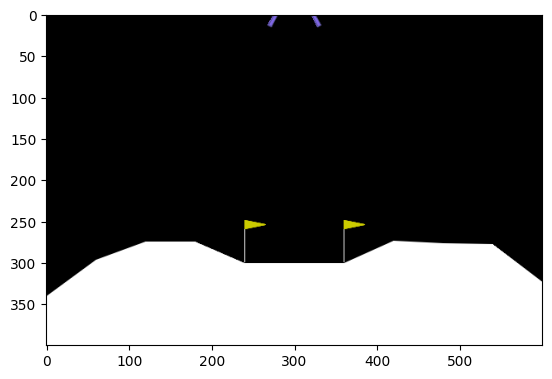

In [2111]:

initial_state = env.observation_space.sample()
initial_state = [float(obs) for obs in initial_state]


from gymnasium import Wrapper
from gymnasium.envs.box2d.lunar_lander import VIEWPORT_W, VIEWPORT_H, SCALE, FPS, LEG_DOWN
import numpy as np

class StateManipulationWrapper(Wrapper):
    def set_state(self, state: np.ndarray) -> None:
        raise NotImplementedError("Environment-specific implementation required")

class LunarLanderStateWrapper(StateManipulationWrapper):
    def set_state(self, obs: np.ndarray) -> None:
        self.reset()
        
        if len(obs) != 8:
            raise ValueError(f"Expected 8-element observation vector, got {len(obs)}")
        
        x_norm, y_norm, vx_norm, vy_norm, angle, ang_vel_norm, left_contact, right_contact = obs
        
        viewport_w = VIEWPORT_W / SCALE
        viewport_h = VIEWPORT_H / SCALE
        
        world_x = (x_norm * viewport_w / 2) + viewport_w / 2
        world_y = (y_norm * viewport_h / 2) + (self.unwrapped.helipad_y + LEG_DOWN / SCALE)
        
        lander = self.unwrapped.lander
        lander.position = (world_x, world_y)
        lander.linearVelocity.x = vx_norm * (viewport_w / 2) / FPS
        lander.linearVelocity.y = vy_norm * (viewport_h / 2) / FPS
        lander.angle = angle
        lander.angularVelocity = ang_vel_norm * FPS / 20.0
        
        legs = self.unwrapped.legs
        legs[0].ground_contact = bool(left_contact)
        legs[1].ground_contact = bool(right_contact)
        
        lander.awake = True

env = LunarLanderStateWrapper(gym.make("LunarLander-v3", continuous=True, render_mode="rgb_array"))
env.set_state(initial_state)
plt.imshow(env.render())